In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import zipfile
warnings.filterwarnings('ignore')

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import cv2

print("GPU available:", tf.config.list_physical_devices("GPU"))

GPU available: []


In [3]:
from google.colab import files
print("Select your Training.zip file...")
uploaded = files.upload()
print("\nUploaded:", list(uploaded.keys()))

Select your Training.zip file...


Saving Training.zip to Training.zip

Uploaded: ['Training.zip']


In [4]:
ZIP_PATH = 'Training.zip'
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content/')
print("Extraction done.")
print("Contents of /content/:", os.listdir('/content/'))

Extraction done.
Contents of /content/: ['.config', 'Testing', 'Training', 'Training.zip', 'sample_data']


In [5]:
#CELLL 3

Train_path = '/content/Training'
Test_path  = '/content/Testing'

print("=== TRAINING FOLDER ===")
train_folders = sorted([f for f in os.listdir(Train_path) if os.path.isdir(os.path.join(Train_path, f))])
print("Folders:", train_folders)

print("\n=== TESTING FOLDER ===")
test_folders = sorted([f for f in os.listdir(Test_path) if os.path.isdir(os.path.join(Test_path, f))])
print("Folders:", test_folders)

print("\n=== MATCH CHECK ===")
for t, v in zip(train_folders, test_folders):
    print(f"  '{t}' vs '{v}' → {'✅' if t==v else '❌ MISMATCH'}")

# Auto-detect Classes from actual folder names
Classes = train_folders
print("\nAuto-detected Classes:", Classes)

=== TRAINING FOLDER ===
Folders: ['glioma', 'meningioma', 'notumor', 'pituitary']

=== TESTING FOLDER ===
Folders: ['glioma', 'meningioma', 'notumor', 'pituitary']

=== MATCH CHECK ===
  'glioma' vs 'glioma' → ✅
  'meningioma' vs 'meningioma' → ✅
  'notumor' vs 'notumor' → ✅
  'pituitary' vs 'pituitary' → ✅

Auto-detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
#CELL 4

IMAGE_SIZE = 224
BATCH_SIZE = 16

for split, path in [('Training', Train_path), ('Testing', Test_path)]:
    print(f"\n{split}:")
    total = 0
    for cls in Classes:
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            total += count
            print(f"    {cls:15s}: {count:5d} images")
    print(f"    {'TOTAL':15s}: {total:5d}")


Training:
    glioma         :  1400 images
    meningioma     :  1400 images
    notumor        :  1400 images
    pituitary      :  1400 images
    TOTAL          :  5600

Testing:
    glioma         :   400 images
    meningioma     :   400 images
    notumor        :   400 images
    pituitary      :   400 images
    TOTAL          :  1600


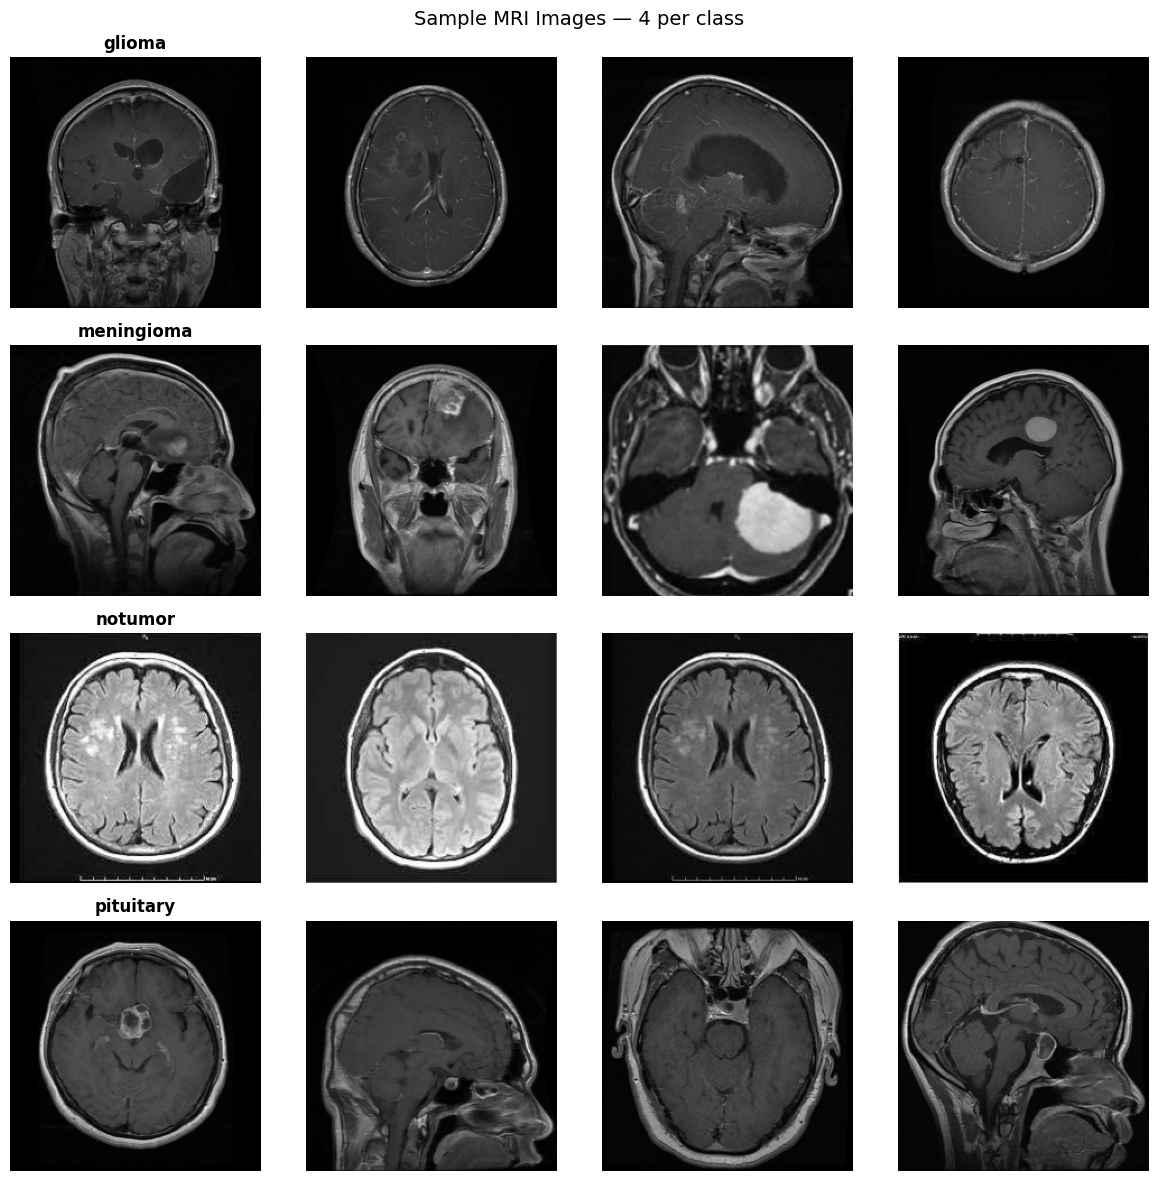

In [7]:
#CELL 5

fig, axes = plt.subplots(len(Classes), 4, figsize=(12, 3*len(Classes)))
fig.suptitle("Sample MRI Images — 4 per class", fontsize=14)

for row, cls in enumerate(Classes):
    cls_dir      = os.path.join(Train_path, cls)
    sample_files = [f for f in os.listdir(cls_dir) if not f.startswith('.')][:4]
    for col, fname in enumerate(sample_files):
        img = cv2.imread(os.path.join(cls_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [8]:
#CELL 6

# MobileNetV2 needs its own preprocess_input, NOT rescale=1./255
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # scales to [-1, 1]
    rotation_range         = 20,
    width_shift_range      = 0.2,
    height_shift_range     = 0.2,
    zoom_range             = 0.2,
    horizontal_flip        = True,
    fill_mode              = 'nearest',
    validation_split       = 0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input    # same preprocessing, no augmentation
)

train_gen = train_datagen.flow_from_directory(
    Train_path,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = 42,
    classes     = Classes
)

val_gen = train_datagen.flow_from_directory(
    Train_path,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = 42,
    classes     = Classes
)

test_gen = test_datagen.flow_from_directory(
    Test_path,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,
    classes     = Classes
)

print("Train indices:", train_gen.class_indices)
print("Val   indices:", val_gen.class_indices)
print("Test  indices:", test_gen.class_indices)

assert train_gen.class_indices == test_gen.class_indices, "❌ MISMATCH!"
print("\n✅ All indices match. Safe to proceed.")
print(f"\nTrain: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Train indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Val   indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Test  indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

✅ All indices match. Safe to proceed.

Train: 4480 | Val: 1120 | Test: 1600


In [9]:
#CELL 7

base_model = MobileNetV2(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
)
base_model.trainable = False   # freeze for Phase 1

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(Classes), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()
print(f"\nOutput classes: {len(Classes)} → {Classes}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,452 (10.01 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Output classes: 4 → ['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
#CELL 8

EPOCHS = 30

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('bestmodel.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

print("Phase 1 training...\n")
history = model.fit(train_gen, validation_data=val_gen,
                    epochs=EPOCHS, callbacks=cbs)
print("Phase 1 done.")

Phase 1 training...

Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.5071 - loss: 1.2640
Epoch 1: val_accuracy improved from None to 0.82768, saving model to bestmodel.keras

Epoch 1: finished saving model to bestmodel.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 259s 903ms/step - accuracy: 0.6161 - loss: 1.0024 - val_accuracy: 0.8277 - val_loss: 0.4779 - learning_rate: 1.0000e-04
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.7589 - loss: 0.6666
Epoch 2: val_accuracy improved from 0.82768 to 0.85446, saving model to bestmodel.keras

Epoch 2: finished saving model to bestmodel.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 251s 898ms/step - accuracy: 0.7638 - loss: 0.6508 - val_accuracy: 0.8545 - val_loss: 0.3946 - learning_rate: 1.0000e-04
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7692 - loss: 0.5907
Epoch 3: val_accuracy did not improve from 0.85446
280/280 ━━━━━━━━━━━━━━━━━━━━ 279s 995ms/step - accuracy: 0.7819 - loss: 0.5754 - val_accura

In [11]:
#CELL 9

# Unfreeze top 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

cbs_ft = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('bestmodel_finetuned.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

print("Phase 2 fine-tuning...\n")
history_ft = model.fit(train_gen, validation_data=val_gen,
                        epochs=20, callbacks=cbs_ft)
print("Fine-tuning done.")

Phase 2 fine-tuning...

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.8127 - loss: 0.4990
Epoch 1: val_accuracy improved from None to 0.86071, saving model to bestmodel_finetuned.keras

Epoch 1: finished saving model to bestmodel_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.8136 - loss: 0.4896 - val_accuracy: 0.8607 - val_loss: 0.3778 - learning_rate: 1.0000e-05
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.8278 - loss: 0.4419
Epoch 2: val_accuracy improved from 0.86071 to 0.88571, saving model to bestmodel_finetuned.keras

Epoch 2: finished saving model to bestmodel_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.8424 - loss: 0.4119 - val_accuracy: 0.8857 - val_loss: 0.3105 - learning_rate: 1.0000e-05
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.8502 - loss: 0.3876
Epoch 3: val_accuracy improved from 0.88571 to 0.90536, saving model to bestmodel_finetuned.keras

Epoch 

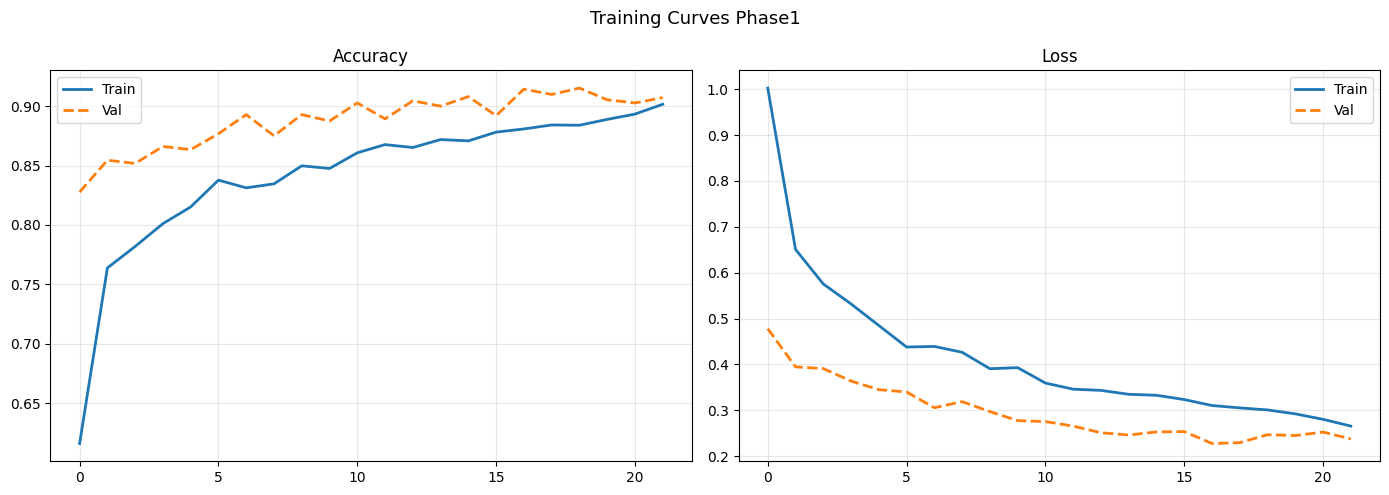

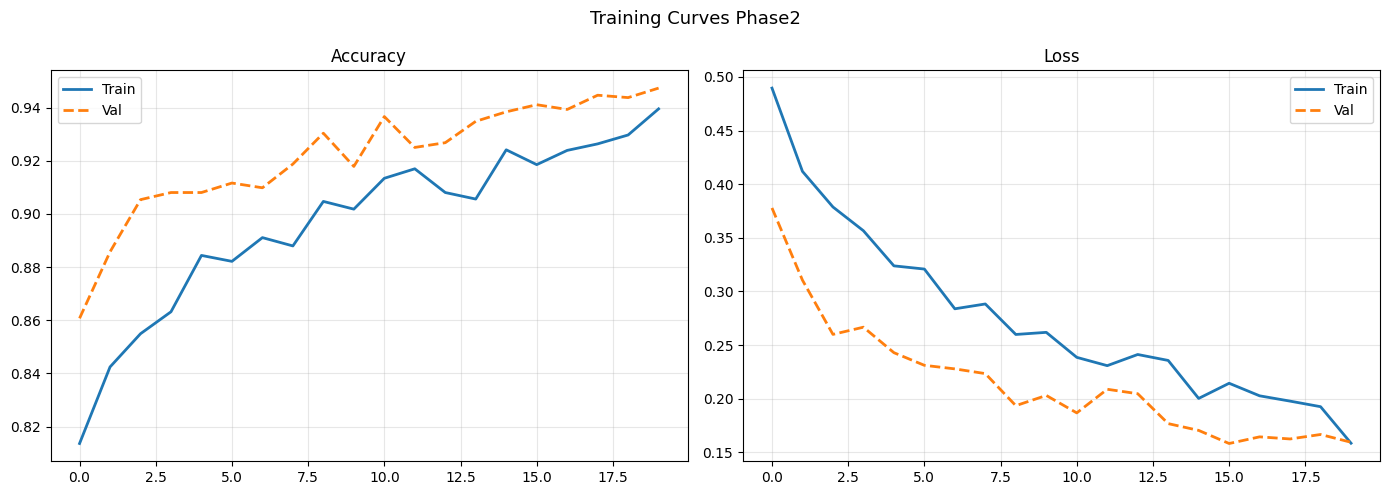

In [12]:
#CELL 10

def plot_history(hist, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training Curves {title}", fontsize=13)
    ax1.plot(hist.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(hist.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(hist.history['loss'],     label='Train', linewidth=2)
    ax2.plot(hist.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    ax2.set_title("Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"curves_{title}.png", dpi=150)
    plt.show()

plot_history(history,    "Phase1")
plot_history(history_ft, "Phase2")

In [13]:
#CELL 11

ckpt = 'bestmodel_finetuned.keras' if os.path.exists('bestmodel_finetuned.keras') else 'bestmodel.keras'
model = tf.keras.models.load_model(ckpt)
print(f"Loaded: {ckpt}")

test_gen.reset()
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

Loaded: bestmodel_finetuned.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 548ms/step - accuracy: 0.9062 - loss: 0.3632

Test Accuracy : 90.62%
Test Loss     : 0.3632


100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 538ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.74      0.84       400
  meningioma       0.82      0.90      0.86       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.91      0.98      0.95       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600



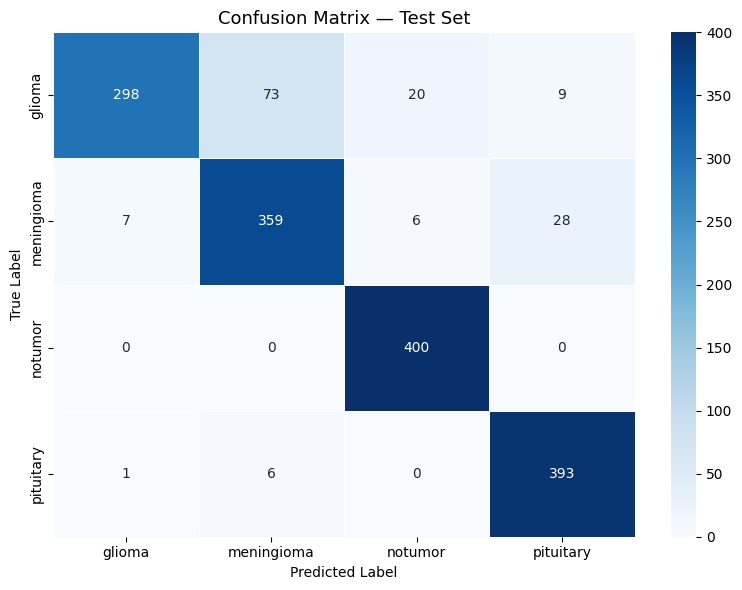

In [14]:
#CELL 12

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=Classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=Classes, yticklabels=Classes, linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
model.save('brain_tumor_mobilenetv2.keras')

from google.colab import files
for f in ['brain_tumor_mobilenetv2.keras', 'bestmodel.keras',
          'bestmodel_finetuned.keras', 'confusion_matrix.png',
          'curves_Phase1.png', 'curves_Phase2.png', 'sample_images.png']:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: brain_tumor_mobilenetv2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: curves_Phase2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: sample_images.png
